In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
import plotly.express as px
warnings.filterwarnings('ignore')

In [ ]:
traffic_data = pd.read_csv("/content/sample_data/traffic_flow_data.csv")
signal_data = pd.read_csv("/content/sample_data/signal_timings_data.csv")
print(traffic_data.head())
print(signal_data.head())
print(traffic_data.isnull().sum())
print(signal_data.isnull().sum())
print(traffic_data.describe())
print(signal_data.describe())
print(traffic_data.dtypes)

     Intersection  Hour      Vehicle_Type  Vehicle_Count
0  Intersection_6    20               Car            357
1  Intersection_1     4  Public Transport            308
2  Intersection_4    16       Two-Wheeler            382
3  Intersection_4     3       Company Bus            207
4  Intersection_8     7  Public Transport             59
     Intersection  Green_Light_Duration  Red_Light_Duration
0  Intersection_1                   107                  87
1  Intersection_2                    41                  47
2  Intersection_3                    43                 119
3  Intersection_4                   111                 115
4  Intersection_5                    56                  85
Intersection     0
Hour             0
Vehicle_Type     0
Vehicle_Count    0
dtype: int64
Intersection            0
Green_Light_Duration    0
Red_Light_Duration      0
dtype: int64
            Hour  Vehicle_Count
count  240.00000     240.000000
mean    11.56250     274.029167
std      7.08734     1

# 1. Patterns and trends in traffic flow at different intersections and times of the day

### A. Traffic in Peak and Off-Peak Traffic Hours

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
hourly_traffic = traffic_data.groupby("Hour")["Vehicle_Count"].sum().reset_index()
fig = px.line(hourly_traffic, x="Hour", y="Vehicle_Count", markers=True,
              title="Traffic Flow by Hour", labels={"Hour": "Hour of the Day", "Vehicle_Count": "Total Vehicles"})
fig.add_shape(type="rect", x0=7, x1=10, y0=0, y1=hourly_traffic["Vehicle_Count"].max(),
              fillcolor="red", opacity=0.2, layer="below", line_width=0)
fig.add_shape(type="rect", x0=17, x1=20, y0=0, y1=hourly_traffic["Vehicle_Count"].max(),
              fillcolor="red", opacity=0.2, layer="below", line_width=0)
fig.add_trace(go.Scatter(x=[None], y=[None], mode='markers',
                         marker=dict(size=10, color="red", opacity=0.4),
                         name="Morning Peak (7-10 AM)"))
fig.add_trace(go.Scatter(x=[None], y=[None], mode='markers',
                         marker=dict(size=10, color="red", opacity=0.4),
                         name="Evening Peak (5-8 PM)"))
fig.show()

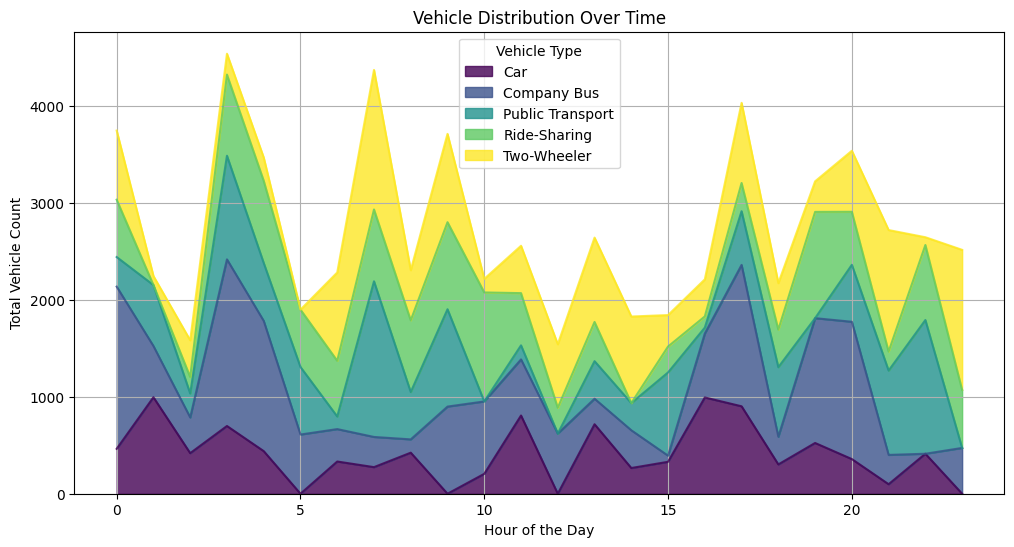

In [ ]:
vehicle_distribution = traffic_data.groupby(["Hour", "Vehicle_Type"])["Vehicle_Count"].sum().reset_index()
vehicle_pivot = vehicle_distribution.pivot(index="Hour", columns="Vehicle_Type", values="Vehicle_Count")

vehicle_pivot.plot(kind="area", stacked=True, figsize=(12, 6), colormap="viridis", alpha=0.8)
plt.title("Vehicle Distribution Over Time")
plt.xlabel("Hour of the Day")
plt.ylabel("Total Vehicle Count")
plt.legend(title="Vehicle Type")
plt.grid(True)
plt.show()


Here we can in peek hours the most vehicles are crowded at intersections at time 7 am (4367 vehicle count)and 5 pm (4028 vehicle count) which makes the intersection most congested so we can implement some algorithm to reduce congestion at these time

## B.Traffic Volume Across Different Intersections

In [ ]:
intersection_traffic = traffic_data.groupby("Intersection")["Vehicle_Count"].sum().reset_index()
fig = px.bar(intersection_traffic, x="Intersection", y="Vehicle_Count",
             color="Vehicle_Count",
             color_continuous_scale="viridis",
             title="Traffic Flow by Intersection",
             labels={"Intersection": "Intersection", "Vehicle_Count": "Total Vehicle Count"})
fig.update_layout(xaxis_tickangle=-45)
fig.show()

We can see that HIghest traffic is at Intersection 4 and Intersection 9 and intersection 1 and so on.

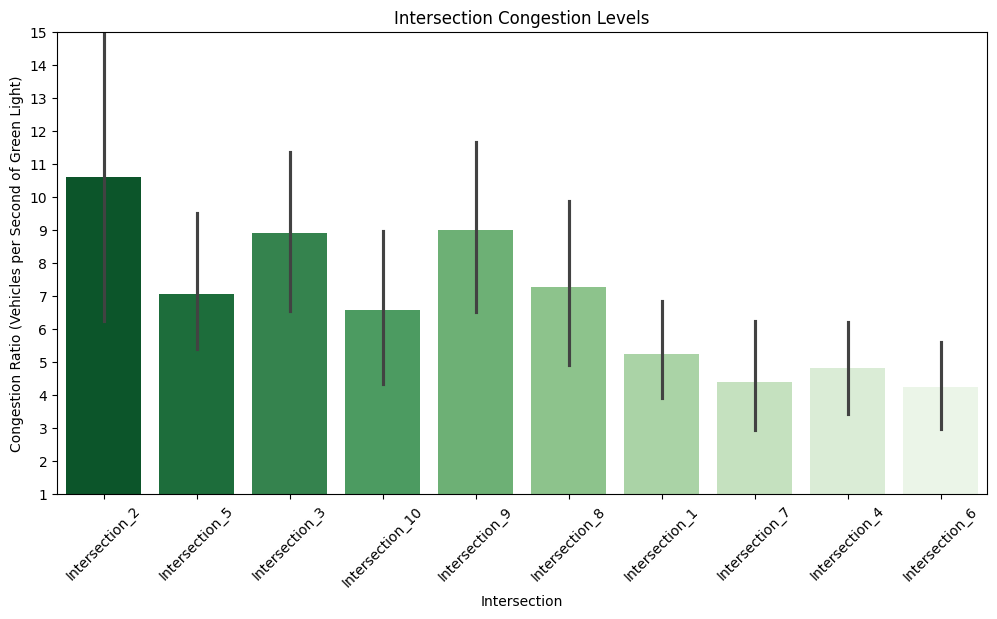

In [ ]:
merged_data["congestion_ratio"] = merged_data["Vehicle_Count"] / merged_data["Green_Light_Duration"]
sorted_congestion = merged_data.sort_values("congestion_ratio", ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x="Intersection", y="congestion_ratio", data=sorted_congestion, palette="Greens_r")
plt.xlabel("Intersection")
plt.ylabel("Congestion Ratio (Vehicles per Second of Green Light)")
plt.title("Intersection Congestion Levels")
plt.xticks(rotation=45)
plt.ylim(1, 15)
plt.yticks(range(1, 16))
plt.show()

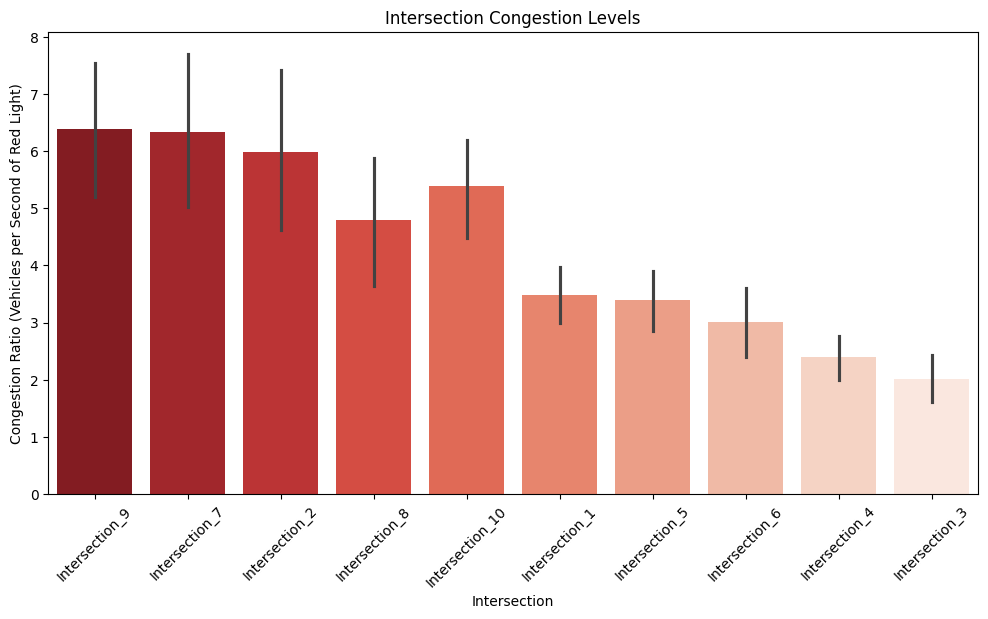

In [ ]:
merged_data["congestion_ratio"] = merged_data["Vehicle_Count"] / merged_data["Red_Light_Duration"]
sorted_congestion = merged_data.sort_values("congestion_ratio", ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x="Intersection", y="congestion_ratio", data=sorted_congestion, palette="Reds_r")
plt.xlabel("Intersection")
plt.ylabel("Congestion Ratio (Vehicles per Second of Red Light)")
plt.title("Intersection Congestion Levels")
plt.xticks(rotation=45)
plt.show()


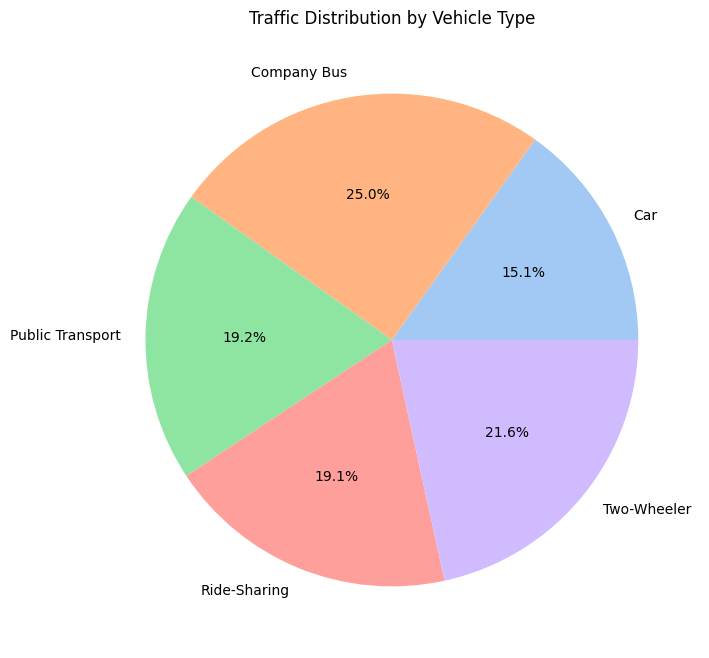

In [ ]:

vehicle_type_traffic = traffic_data.groupby("Vehicle_Type")["Vehicle_Count"].sum().reset_index()
plt.figure(figsize=(8, 8))
plt.pie(vehicle_type_traffic["Vehicle_Count"], labels=vehicle_type_traffic["Vehicle_Type"], autopct="%1.1f%%", colors=sns.color_palette("pastel"))
plt.title("Traffic Distribution by Vehicle Type")
plt.show()


The most vehicle type which contributs in traffic is Company bus and then two-wheeler so main aim is to modify the traffic signal light when these type appears most time.

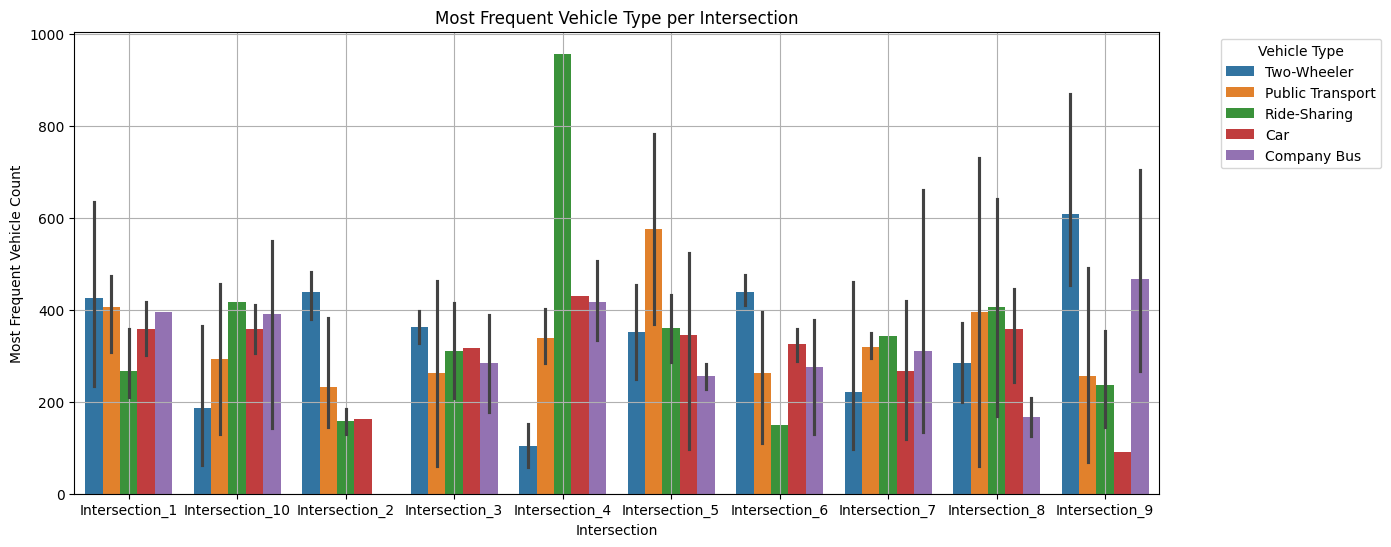

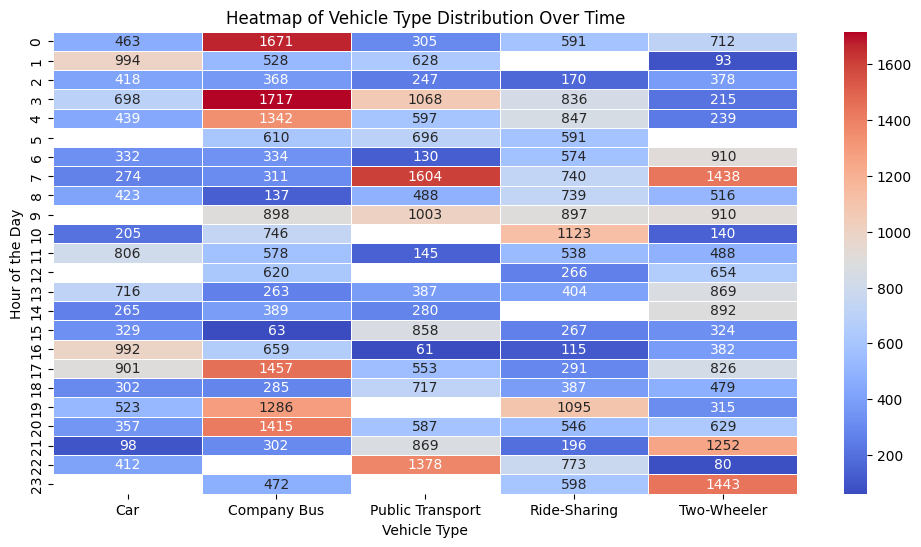

In [ ]:
vehicle_type_analysis = traffic_data.groupby(["Intersection", "Hour", "Vehicle_Type"])["Vehicle_Count"].sum().reset_index()

most_common_vehicle = vehicle_type_analysis.loc[vehicle_type_analysis.groupby(["Intersection", "Hour"])["Vehicle_Count"].idxmax()]
vehicle_pivot = vehicle_type_analysis.pivot_table(index="Hour", columns="Vehicle_Type", values="Vehicle_Count", aggfunc="sum")
plt.figure(figsize=(14, 6))
sns.barplot(data=most_common_vehicle, x="Intersection", y="Vehicle_Count", hue="Vehicle_Type", palette="tab10")
plt.xlabel("Intersection")
plt.ylabel("Most Frequent Vehicle Count")
plt.title("Most Frequent Vehicle Type per Intersection")
plt.legend(title="Vehicle Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
sns.heatmap(vehicle_pivot, cmap="coolwarm", annot=True, fmt=".0f", linewidths=0.5)
plt.xlabel("Vehicle Type")
plt.ylabel("Hour of the Day")
plt.title("Heatmap of Vehicle Type Distribution Over Time")
plt.show()


I1: Two wheelers and company bus and transport are mostly observed : Employers and Commuters, I2: Employers are on two-wheelers but no Company Bus services. I3: Employers prefer two-wheelers and professional on car and same amount of people on ride share. I4: Riders are more here and then car and company bus which means that here can be EY's office. I5: Commuters and Professional. I6: Employers and Professional. I7: Balanced Number of vechile count. I8: More Professional and commuters on ride share and public transport. I9: Employers are more here may be a Common Rental Place. I10: Professsional and Employers on company bus.

High-Traffic Intersections is likely major roads, commercial areas, or busy urban centers.Low-Traffic Intersections is intersections may be in residential or less busy areas.

The above plot explains that which vehicle type is most frquent in each intersection and the heatmap explains that for each vehicle type what's it frequence per hour.

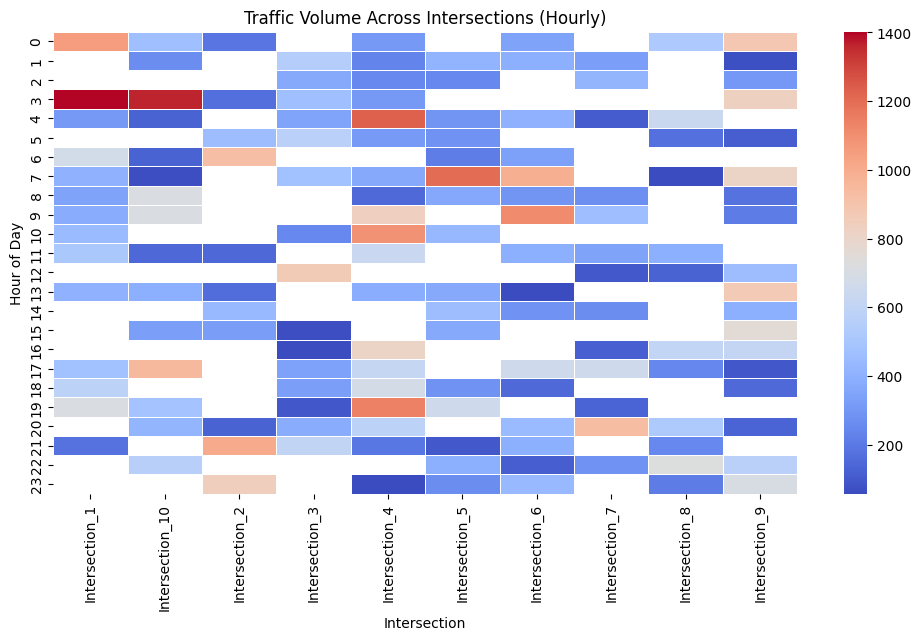

In [ ]:
Hourly_traffic = traffic_data.groupby(["Hour", "Intersection"])["Vehicle_Count"].sum().reset_index()
Hourly_pivot = Hourly_traffic.pivot(index="Hour", columns="Intersection", values="Vehicle_Count")
plt.figure(figsize=(12, 6))
sns.heatmap(Hourly_pivot, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Traffic Volume Across Intersections (Hourly)")
plt.xlabel("Intersection")
plt.ylabel("Hour of Day")
plt.show()


## C. Relationship between traffic flow and traffic signal timings.

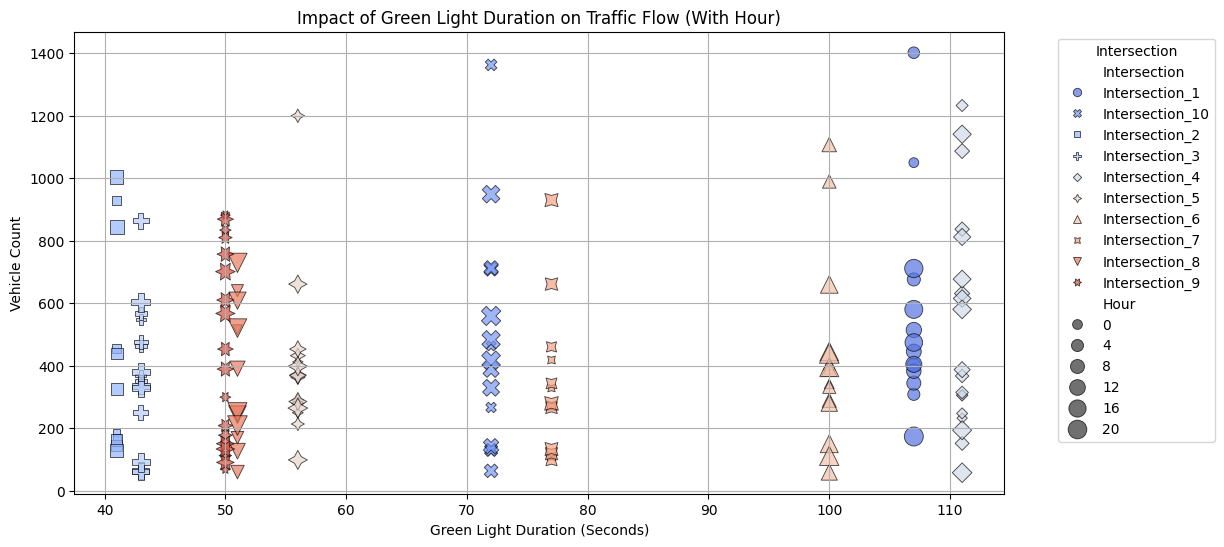

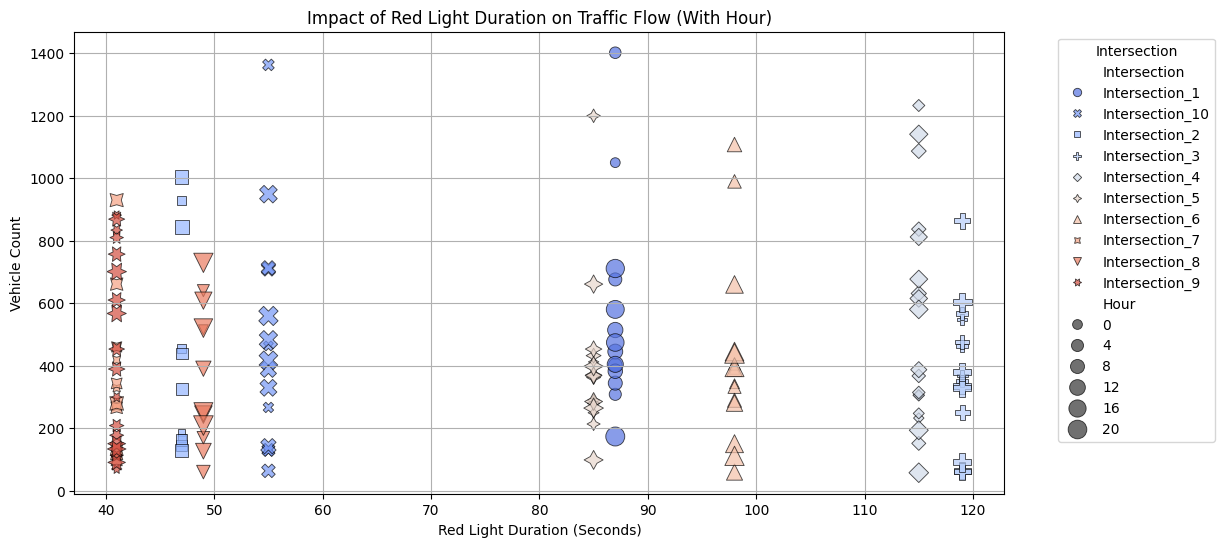

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=merged_t,
    x="Green_Light_Duration",
    y="Vehicle_Count",
    hue="Intersection",
    size="Hour",
    sizes=(50, 200),
    palette="coolwarm",
    style="Intersection",
    edgecolor="black",
    alpha=0.7
)
plt.xlabel("Green Light Duration (Seconds)")
plt.ylabel("Vehicle Count")
plt.title("Impact of Green Light Duration on Traffic Flow (With Hour)")
plt.legend(title="Intersection", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=merged_t,
    x="Red_Light_Duration",
    y="Vehicle_Count",
    hue="Intersection",
    size="Hour",
    sizes=(50, 200),
    palette="coolwarm",
    style="Intersection",
    edgecolor="black",
    alpha=0.7
)
plt.xlabel("Red Light Duration (Seconds)")
plt.ylabel("Vehicle Count")
plt.title("Impact of Red Light Duration on Traffic Flow (With Hour)")
plt.legend(title="Intersection", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd

# Define function to analyze traffic patterns
def analyze_traffic_patterns(data):
    insights = []

    for intersection in data["Intersection"].unique():
        subset = data[data["Intersection"] == intersection]
        green_corr = subset["Green_Light_Duration"].corr(subset["Vehicle_Count"])
        red_corr = subset["Red_Light_Duration"].corr(subset["Vehicle_Count"])
        peak_hours = subset.nlargest(3, "Vehicle_Count")["Hour"].tolist()

        insights.append({
            "Intersection": intersection,
            "Peak_Hours": peak_hours
        })

    return pd.DataFrame(insights)
traffic_insights = analyze_traffic_patterns(merged_t)

print(traffic_insights)


    Intersection    Peak_Hours 
0   Intersection_1   [3, 0, 19]
1  Intersection_10   [3, 17, 9]
2   Intersection_2  [21, 6, 23]
3   Intersection_3  [12, 21, 5]
4   Intersection_4  [4, 19, 10]
5   Intersection_5  [7, 19, 14]
6   Intersection_6   [9, 7, 17]
7   Intersection_7  [20, 17, 9]
8   Intersection_8  [22, 4, 16]
9   Intersection_9   [0, 13, 3]


In [ ]:
import pandas as pd
import plotly.express as px
traffic_data["Intersection"] = traffic_data["Intersection"].astype("category")
merged_data = traffic_data.merge(signal_data, on="Intersection")
fig1 = px.bar(
    merged_data,
    x="Intersection",
    y="Vehicle_Count",
    color="Green_Light_Duration",
    title="Vehicle Count vs Green Light Duration",
    labels={"Vehicle_Count": "Vehicle Count", "Intersection": "Intersection"},
    barmode="group",
    color_continuous_scale="blues"
)
fig1.update_layout(xaxis_tickangle=-45)
fig1.show()
fig2 = px.bar(
    merged_data,
    x="Intersection",
    y="Vehicle_Count",
    color="Red_Light_Duration",
    title="Vehicle Count vs Red Light Duration",
    labels={"Vehicle_Count": "Vehicle Count", "Intersection": "Intersection"},
    barmode="group",
    color_continuous_scale="reds"
)
fig2.update_layout(xaxis_tickangle=-45)
fig2.show()


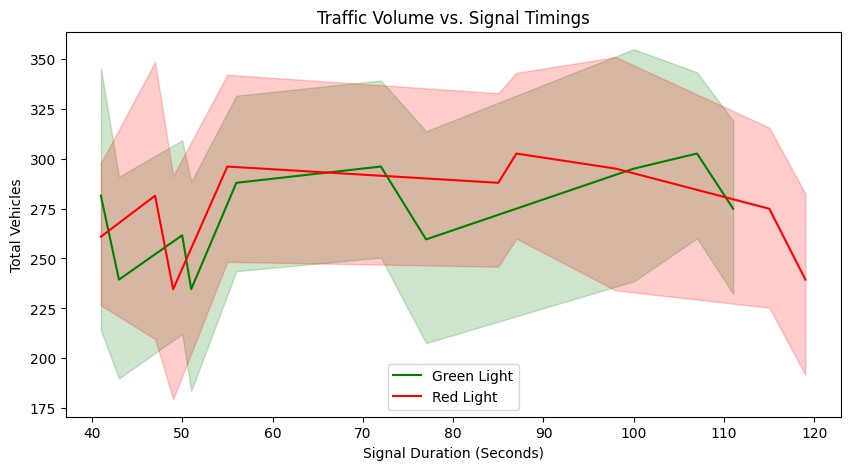

In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(x="Green_Light_Duration", y="Vehicle_Count", data=merged_data, color="green", label="Green Light")
sns.lineplot(x="Red_Light_Duration", y="Vehicle_Count", data=merged_data, color="red", label="Red Light")
plt.xlabel("Signal Duration (Seconds)")
plt.ylabel("Total Vehicles")
plt.title("Traffic Volume vs. Signal Timings")
plt.legend()
plt.show()

    Intersection    Vehicle_Count  Green_Light_Duration  Red_Light_Duration
0   Intersection_1       7865               107                   87       
1  Intersection_10       7104                72                   55       
2   Intersection_2       4784                41                   47       
3   Intersection_3       5746                43                  119       
4   Intersection_4      10171               111                  115       
5   Intersection_5       6333                56                   85       
6   Intersection_6       6784               100                   98       
7   Intersection_7       4412                77                   41       
8   Intersection_8       4458                51                   49       
9   Intersection_9       8110                50                   41       


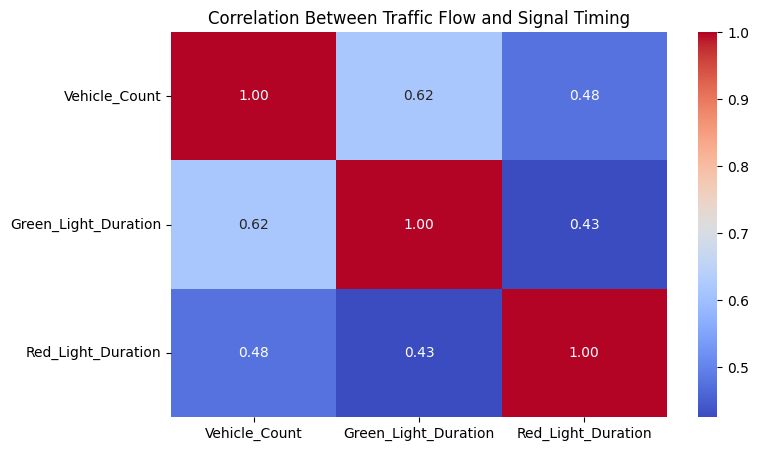

In [ ]:
merged_data = traffic_data.groupby("Intersection")["Vehicle_Count"].sum().reset_index()
merged_data = merged_data.merge(signal_data, on="Intersection")
print(merged_data)
correlation = merged_data.drop(columns=["Intersection"]).corr()
plt.figure(figsize=(8, 5))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Traffic Flow and Signal Timing")
plt.show()


The above corelation explains that 62% time vehicle are passing green light signal and 48% wait in red light signal for total intersection.

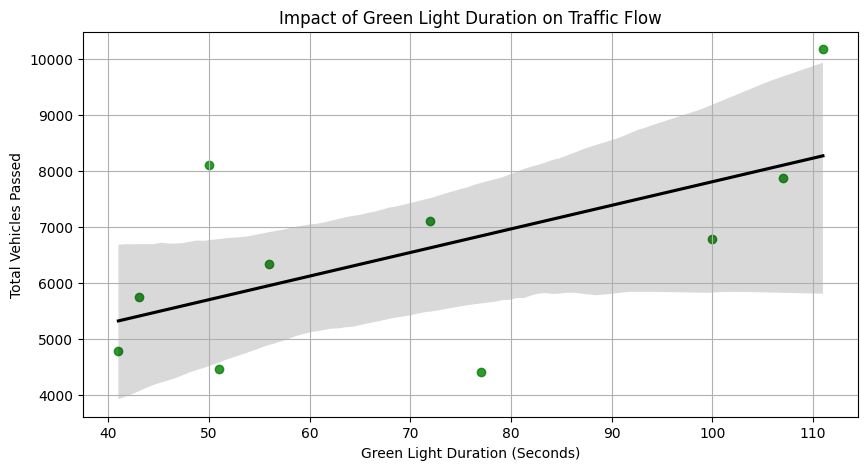

In [ ]:

merged_data = traffic_data.groupby("Intersection")["Vehicle_Count"].sum().reset_index()
merged_data = merged_data.merge(signal_data, on="Intersection")
plt.figure(figsize=(10, 5))
sns.regplot(x="Green_Light_Duration", y="Vehicle_Count", data=merged_data, scatter_kws={"color": "green"}, line_kws={"color": "black"})
plt.xlabel("Green Light Duration (Seconds)")
plt.ylabel("Total Vehicles Passed")
plt.title("Impact of Green Light Duration on Traffic Flow")
plt.grid(True)
plt.show()


Intersection            object
Vehicle_Count            int64
Green_Light_Duration     int64
Red_Light_Duration       int64
dtype: object


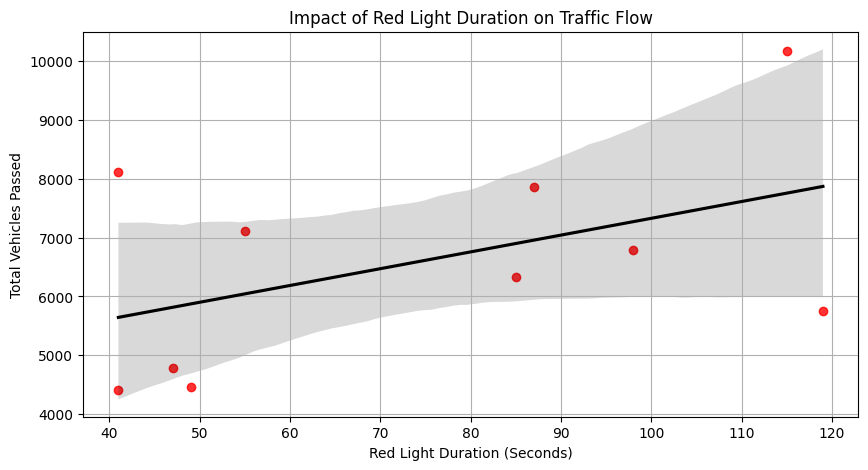

In [ ]:
merged_data = traffic_data.groupby("Intersection")["Vehicle_Count"].sum().reset_index()
merged_data = merged_data.merge(signal_data, on="Intersection")
plt.figure(figsize=(10, 5))
sns.regplot(x="Red_Light_Duration", y="Vehicle_Count", data=merged_data, scatter_kws={"color": "red"}, line_kws={"color": "black"})
plt.xlabel("Red Light Duration (Seconds)")
plt.ylabel("Total Vehicles Passed")
plt.title("Impact of Red Light Duration on Traffic Flow")
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd

# Merge traffic data with signal timing data
merged_t = traffic_data.merge(signal_data, on="Intersection", how="inner")

# Group by Intersection and Hour, summing up the Vehicle_Count
merged_t = merged_t.groupby(["Intersection", "Hour"], as_index=False).agg({
    "Vehicle_Count": "sum",
    "Green_Light_Duration": "mean",
    "Red_Light_Duration": "mean"
})

merged_t["Rolling_Avg_Vehicles"] = merged_t.groupby("Intersection")["Vehicle_Count"].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

# Apply expanding window (cumulative average) to track long-term trends
merged_t["Cumulative_Avg_Vehicles"] = merged_t.groupby("Intersection")["Vehicle_Count"].transform(lambda x: x.expanding().mean())

merged_t["Rolling_Avg_Vehicles"] = merged_t["Rolling_Avg_Vehicles"].round(0).astype(int)
merged_t["Cumulative_Avg_Vehicles"] = merged_t["Cumulative_Avg_Vehicles"].round(0).astype(int)
merged_t["Green_Light_Duration"] = merged_t["Green_Light_Duration"].astype(int)
merged_t["Red_Light_Duration"] = merged_t["Red_Light_Duration"].astype(int)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print(merged_t)
# merged_t.to_csv('merged_traffic_data.csv', index=False)



        Intersection  Hour  Vehicle_Count  Green_Light_Duration  Red_Light_Duration  Rolling_Avg_Vehicles  Cumulative_Avg_Vehicles
0     Intersection_1     0           1050                   107                  87                  1050                     1050
1     Intersection_1     3           1402                   107                  87                  1226                     1226
2     Intersection_1     4            308                   107                  87                   920                      920
3     Intersection_1     6            676                   107                  87                   795                      859
4     Intersection_1     7            402                   107                  87                   462                      768
5     Intersection_1     8            344                   107                  87                   474                      697
6     Intersection_1     9            382                   107                  87

In [ ]:
import pandas as pd

# Store correlation results
correlation_results = []

# Compute correlation per intersection
for intersection in merged_t["Intersection"].unique():
    subset = merged_t[merged_t["Intersection"] == intersection]

    # Check if there are at least two data points for correlation calculation
    if subset.shape[0] > 1:
        corr_value = subset["Hour"].corr(subset["Vehicle_Count"])
    else:
        corr_value = None  # Correlation can't be calculated with only one data point

    correlation_results.append({
        "Intersection": intersection,
        "Correlation_Hour_VehicleCount": corr_value
    })

# Convert results to DataFrame
correlation_df = pd.DataFrame(correlation_results)

# Display correlation values
print(correlation_df)

# Sort intersections by highest congestion correlation
correlation_df_sorted = correlation_df.sort_values(by="Correlation_Hour_VehicleCount", ascending=False)

# Print sorted correlations
print("\nSorted Intersections by Congestion (Hour vs. Vehicle Count Correlation):")
print(correlation_df_sorted)


    Intersection    Correlation_Hour_VehicleCount
0   Intersection_1           -0.465177           
1  Intersection_10            0.065028           
2   Intersection_2            0.353978           
3   Intersection_3           -0.296307           
4   Intersection_4            0.122788           
5   Intersection_5           -0.102489           
6   Intersection_6           -0.200257           
7   Intersection_7            0.219000           
8   Intersection_8            0.065908           
9   Intersection_9           -0.023610           

Sorted Intersections by Congestion (Hour vs. Vehicle Count Correlation):
    Intersection    Correlation_Hour_VehicleCount
2   Intersection_2            0.353978           
7   Intersection_7            0.219000           
4   Intersection_4            0.122788           
8   Intersection_8            0.065908           
1  Intersection_10            0.065028           
9   Intersection_9           -0.023610           
5   Intersection_5        

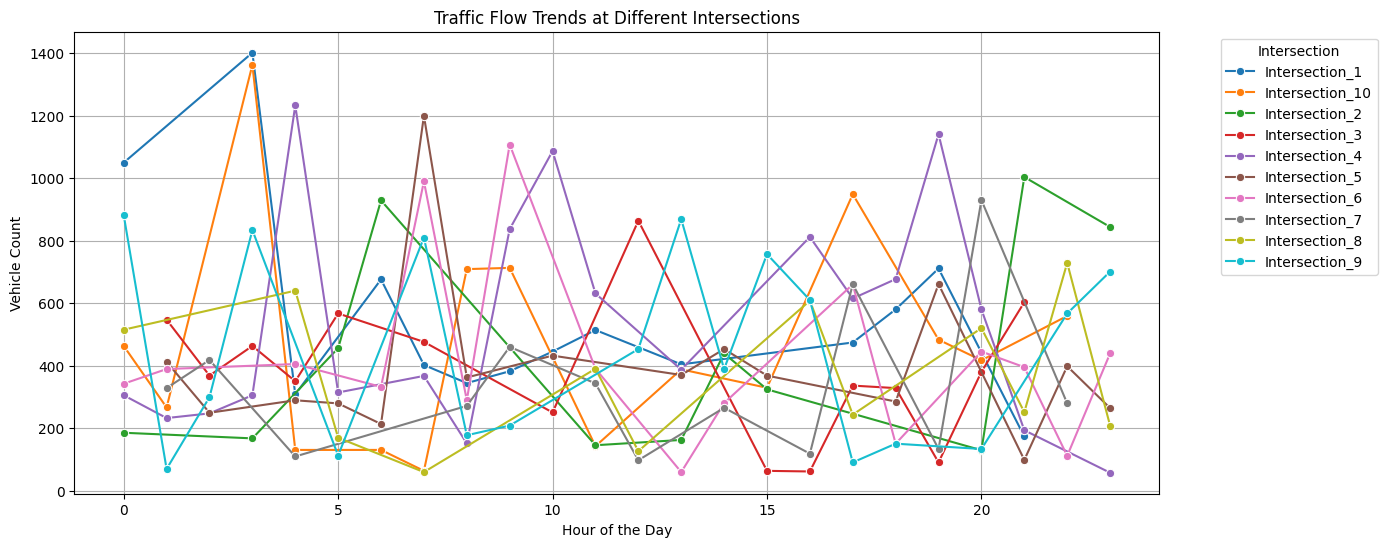

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Line plot: Vehicle Count vs. Hour for different intersections
plt.figure(figsize=(14, 6))
sns.lineplot(data=merged_t, x="Hour", y="Vehicle_Count", hue="Intersection", marker="o", palette="tab10")
plt.xlabel("Hour of the Day")
plt.ylabel("Vehicle Count")
plt.title("Traffic Flow Trends at Different Intersections")
plt.legend(title="Intersection", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


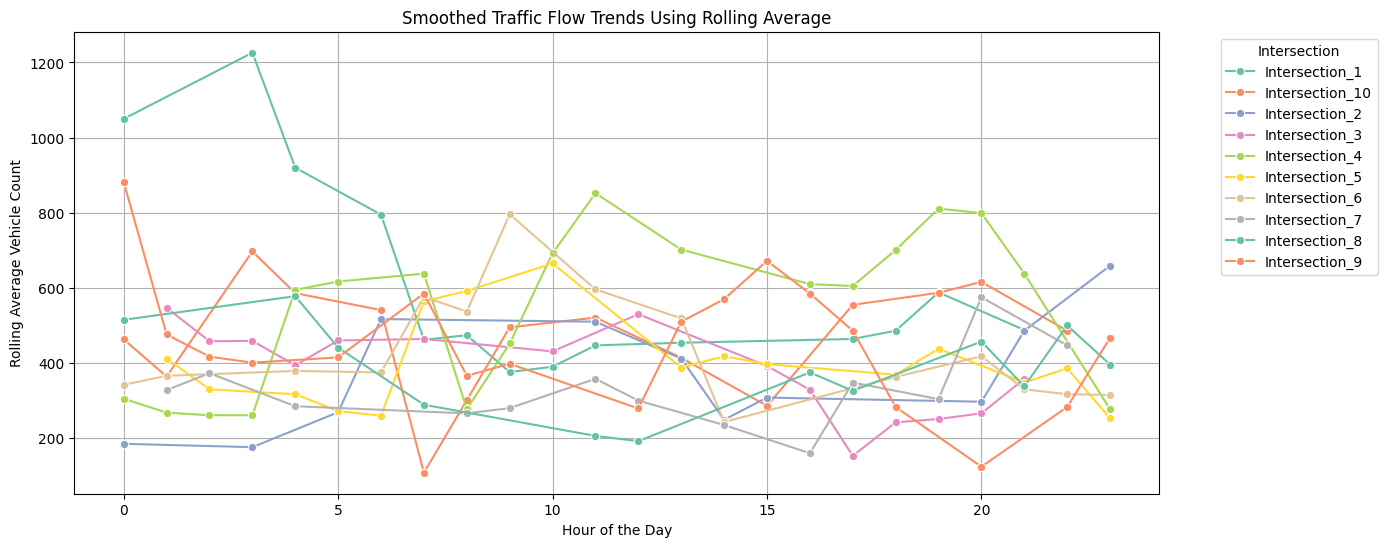

In [ ]:
# Line plot for rolling average traffic trend
plt.figure(figsize=(14, 6))
sns.lineplot(data=merged_t, x="Hour", y="Rolling_Avg_Vehicles", hue="Intersection", marker="o", palette="Set2")
plt.xlabel("Hour of the Day")
plt.ylabel("Rolling Average Vehicle Count")
plt.title("Smoothed Traffic Flow Trends Using Rolling Average")
plt.legend(title="Intersection", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd

# Compute total vehicle count per intersection and merge with signal data
merged_data = traffic_data.groupby("Intersection")["Vehicle_Count"].sum().reset_index()
merged_data = merged_data.merge(signal_data, on="Intersection")

# **🔹 Compute Correlation Between Traffic and Signal Durations**
green_corr = merged_data["Green_Light_Duration"].corr(merged_data["Vehicle_Count"])
red_corr = merged_data["Red_Light_Duration"].corr(merged_data["Vehicle_Count"])

# **🔹 Function to Optimize Green and Red Light Durations**
def optimize_signal_timings(row):
    optimized_green = row["Green_Light_Duration"]
    optimized_red = row["Red_Light_Duration"]

    # Adjust Green Light Duration Based on Traffic Volume
    if green_corr > 0.5:
        optimized_green += 10  # Increase green light duration
    elif green_corr < -0.5:
        optimized_green -= 5  # Reduce green light duration

    # Adjust Red Light Duration Based on Traffic Volume
    if red_corr < -0.5:
        optimized_red -= 5  # Reduce red light duration
    elif red_corr > 0.5:
        optimized_red += 10  # Increase red light duration

    return pd.Series([optimized_green, optimized_red])

# **🔹 Apply Optimization Function to Each Intersection**
merged_data[["Optimized_Green_Light", "Optimized_Red_Light"]] = merged_data.apply(optimize_signal_timings, axis=1)

# **🔹 Identify Intersections Needing Layout Changes**
congested_intersections = merged_data[merged_data["Vehicle_Count"] > merged_data["Vehicle_Count"].quantile(0.75)]["Intersection"].tolist()

# **🔹 Recommend Alternate Routes for High-Traffic Intersections**
alternate_routes = {intersection: f"Suggest alternate route for {intersection}" for intersection in congested_intersections}

# **🔹 Print Optimization Recommendations**
print("\n🔹 **Traffic Signal Optimization Results** 🔹")

print("\n✅ **Optimized Traffic Signal Timings**:")
print(merged_data[["Intersection", "Vehicle_Count", "Optimized_Green_Light", "Optimized_Red_Light"]])

print("\n✅ **Intersections Needing Layout Changes**:")
print(congested_intersections)

print("\n✅ **Suggested Alternate Routes for Congested Intersections**:")
print(alternate_routes)


0.4756171204400711

🔹 **Traffic Signal Optimization Results** 🔹

✅ **Optimized Traffic Signal Timings**:
    Intersection    Vehicle_Count  Optimized_Green_Light  Optimized_Red_Light
0   Intersection_1       7865               117                    87        
1  Intersection_10       7104                82                    55        
2   Intersection_2       4784                51                    47        
3   Intersection_3       5746                53                   119        
4   Intersection_4      10171               121                   115        
5   Intersection_5       6333                66                    85        
6   Intersection_6       6784               110                    98        
7   Intersection_7       4412                87                    41        
8   Intersection_8       4458                61                    49        
9   Intersection_9       8110                60                    41        

✅ **Intersections Needing Layout Cha

In [ ]:
import pandas as pd

# **🔹 Group data to find the total count of each vehicle type per intersection and hour**
vehicle_type_analysis = traffic_data.groupby(["Intersection", "Hour", "Vehicle_Type"])["Vehicle_Count"].sum().reset_index()

# **🔹 Identify peak hour for each vehicle type at every intersection**
peak_hours = vehicle_type_analysis.loc[vehicle_type_analysis.groupby(["Intersection", "Vehicle_Type"])["Vehicle_Count"].idxmax()]

# **🔹 Display the peak hours**
print("\n🔹 **Peak Hour for Each Vehicle Type at Every Intersection** 🔹")
print(peak_hours[["Intersection", "Vehicle_Type", "Hour", "Vehicle_Count"]])

# **🔹 Save peak hour analysis to CSV (optional)**
peak_hours.to_csv("Peak_Hour_Vehicle_Analysis.csv", index=False)
print("\n✅ Data saved to 'Peak_Hour_Vehicle_Analysis.csv'")



🔹 **Peak Hour for Each Vehicle Type at Every Intersection** 🔹
       Intersection      Vehicle_Type    Hour  Vehicle_Count
55     Intersection_1               Car   11        416     
16     Intersection_1       Company Bus    3        424     
87     Intersection_1  Public Transport   17        474     
68     Intersection_1      Ride-Sharing   13        404     
4      Intersection_1       Two-Wheeler    0        712     
120   Intersection_10               Car    0        463     
136   Intersection_10       Company Bus    3        549     
167   Intersection_10  Public Transport    9        455     
138   Intersection_10      Ride-Sharing    3        441     
164   Intersection_10       Two-Wheeler    8        365     
305    Intersection_2               Car   13        162     
271    Intersection_2       Company Bus    6        121     
267    Intersection_2  Public Transport    5        382     
358    Intersection_2      Ride-Sharing   23        398     
274    Intersection_2 


✅ Model Performance: Mean Absolute Error = 249.80

🔹 **AI-Optimized Traffic Signal Timings** 🔹
     Intersection  Hour  Predicted_Traffic  Optimized_Green_Light  Optimized_Red_Light
0          0         0        723.14                117.0                  82.0       
1          0         1        256.29                107.0                  87.0       
2          0         2        113.85                102.0                  92.0       
3          0         3        988.81                117.0                  82.0       
4          0         4        470.85                117.0                  82.0       
5          0         5        134.11                102.0                  92.0       
6          0         6        170.87                102.0                  92.0       
7          0         7        385.54                107.0                  87.0       
8          0         8        396.90                107.0                  87.0       
9          0         9        480.

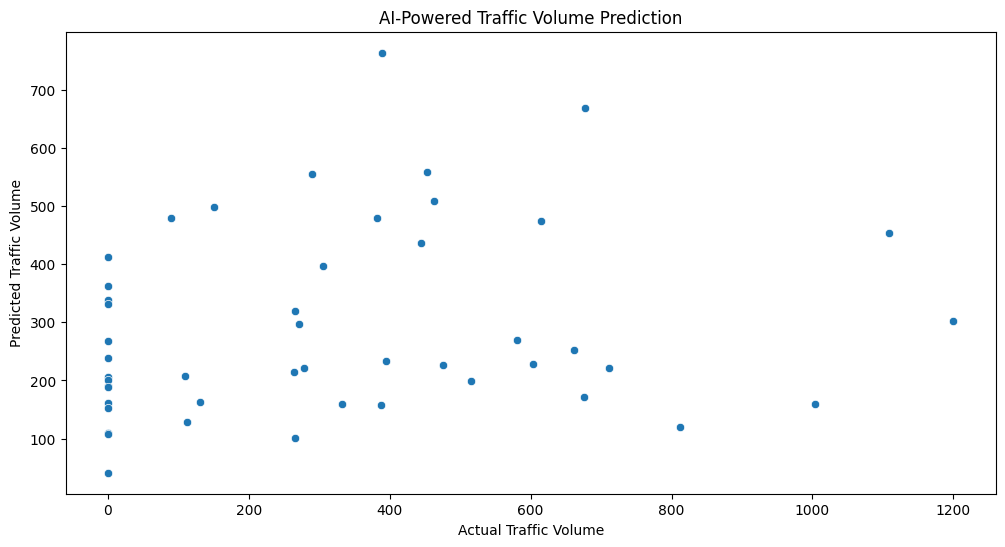

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# **🔹 Load and Merge Traffic Data (Remove Vehicle Type Dependency)**
merged_data = traffic_data.groupby(["Intersection", "Hour"])["Vehicle_Count"].sum().reset_index()
merged_data = merged_data.merge(signal_data, on="Intersection")

# **🔹 Feature Engineering**
# Convert categorical Intersection data to numerical labels
merged_data["Intersection"] = merged_data["Intersection"].astype("category").cat.codes

# **🔹 Define Features and Target Variable**
X = merged_data[["Intersection", "Hour", "Green_Light_Duration", "Red_Light_Duration"]]
y = merged_data["Vehicle_Count"]

# **🔹 Split Data for Training and Testing**
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **🔹 Train the AI Model**
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# **🔹 Predict Traffic Volume**
y_pred = model.predict(X_test)

# **🔹 Evaluate Model Performance**
mae = mean_absolute_error(y_test, y_pred)
print(f"\n✅ Model Performance: Mean Absolute Error = {mae:.2f}")

# **🔹 Predict Future Traffic for Signal Adjustment**
future_data = X.copy()
future_data["Predicted_Traffic"] = model.predict(X)

def adjust_signal_timing(row):
    if row["Predicted_Traffic"] > 400:
        return row["Green_Light_Duration"] + 10, row["Red_Light_Duration"] - 5
    elif row["Predicted_Traffic"] < 200:
        return row["Green_Light_Duration"] - 5, row["Red_Light_Duration"] + 5
    return row["Green_Light_Duration"], row["Red_Light_Duration"]

future_data[["Optimized_Green_Light", "Optimized_Red_Light"]] = future_data.apply(adjust_signal_timing, axis=1, result_type="expand")

print("\n🔹 **AI-Optimized Traffic Signal Timings** 🔹")
print(future_data[["Intersection", "Hour", "Predicted_Traffic", "Optimized_Green_Light", "Optimized_Red_Light"]])

plt.figure(figsize=(12, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("AI-Powered Traffic Volume Prediction")
plt.show()


In [ ]:
import pandas as pd

# Merge traffic and station data
merged_traffic = traffic_data.groupby(["Intersection", "Hour"], as_index=False)["Vehicle_Count"].sum()
merged_data = merged_traffic.merge(signal_data, on="Intersection", how="inner")

# Sort for time-series analysis
merged_data = merged_data.sort_values(["Intersection", "Hour"])
print(merged_data.head())

     Intersection  Hour  Vehicle_Count  Green_Light_Duration  \
0  Intersection_1     0           1050                   107   
1  Intersection_1     3           1402                   107   
2  Intersection_1     4            308                   107   
3  Intersection_1     6            676                   107   
4  Intersection_1     7            402                   107   

   Red_Light_Duration  
0                  87  
1                  87  
2                  87  
3                  87  
4                  87  


In [ ]:
def adjust_signal_timing(df, scaling_factor=30):
    # df["Prev_Vehicle_Count"] = df.groupby("Intersection")["Vehicle_Count"].shift(1).fillna(0)
    df["Delta_Green"] =((df["Vehicle_Count"]) / scaling_factor)

    # Compute new green/red light durations
    df["Optimized_Green_Light"] = df["Green_Light_Duration"] + df["Delta_Green"]
    df["Optimized_Red_Light"] = df["Red_Light_Duration"] - df["Delta_Green"]
    return df[["Intersection", "Hour", "Vehicle_Count", "Optimized_Green_Light", "Optimized_Red_Light"]]

# Apply the function
optimized_signals = adjust_signal_timing(merged_data)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
print(optimized_signals)

        Intersection  Hour  Vehicle_Count  Optimized_Green_Light  Optimized_Red_Light
0     Intersection_1     0           1050             142.000000            52.000000
1     Intersection_1     3           1402             153.733333            40.266667
2     Intersection_1     4            308             117.266667            76.733333
3     Intersection_1     6            676             129.533333            64.466667
4     Intersection_1     7            402             120.400000            73.600000
5     Intersection_1     8            344             118.466667            75.533333
6     Intersection_1     9            382             119.733333            74.266667
7     Intersection_1    10            445             121.833333            72.166667
8     Intersection_1    11            514             124.133333            69.866667
9     Intersection_1    13            404             120.466667            73.533333
10    Intersection_1    17            474             

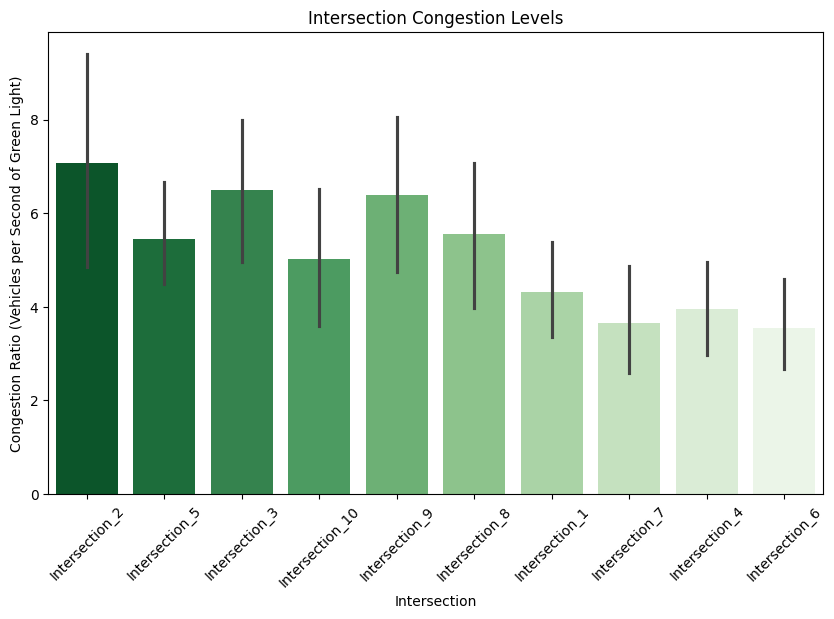

In [ ]:
optimized_signals["congestion_ratio"] = optimized_signals["Vehicle_Count"] / optimized_signals["Optimized_Green_Light"]
sorted_congestion = optimized_signals.sort_values("congestion_ratio", ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x="Intersection", y="congestion_ratio", data=sorted_congestion, palette="Greens_r")
plt.xlabel("Intersection")
plt.ylabel("Congestion Ratio (Vehicles per Second of Green Light)")
plt.title("Intersection Congestion Levels")
plt.xticks(rotation=45)
plt.show()

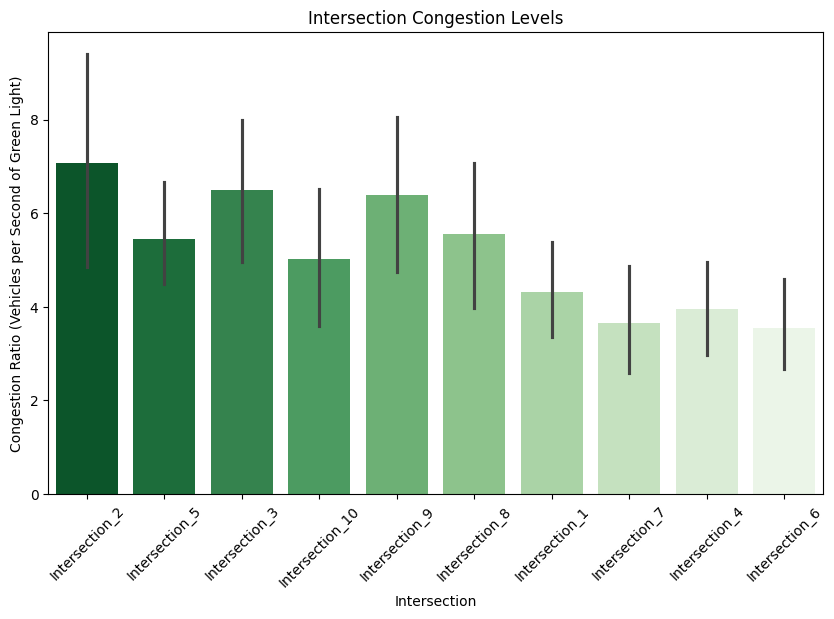

In [ ]:
optimized_signals["congestion_ratio"] = optimized_signals["Vehicle_Count"] / optimized_signals["Optimized_Green_Light"]
sorted_congestion = optimized_signals.sort_values("congestion_ratio", ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x="Intersection", y="congestion_ratio", data=sorted_congestion, palette="Greens_r")
plt.xlabel("Intersection")
plt.ylabel("Congestion Ratio (Vehicles per Second of Green Light)")
plt.title("Intersection Congestion Levels")
plt.xticks(rotation=45)
plt.show()

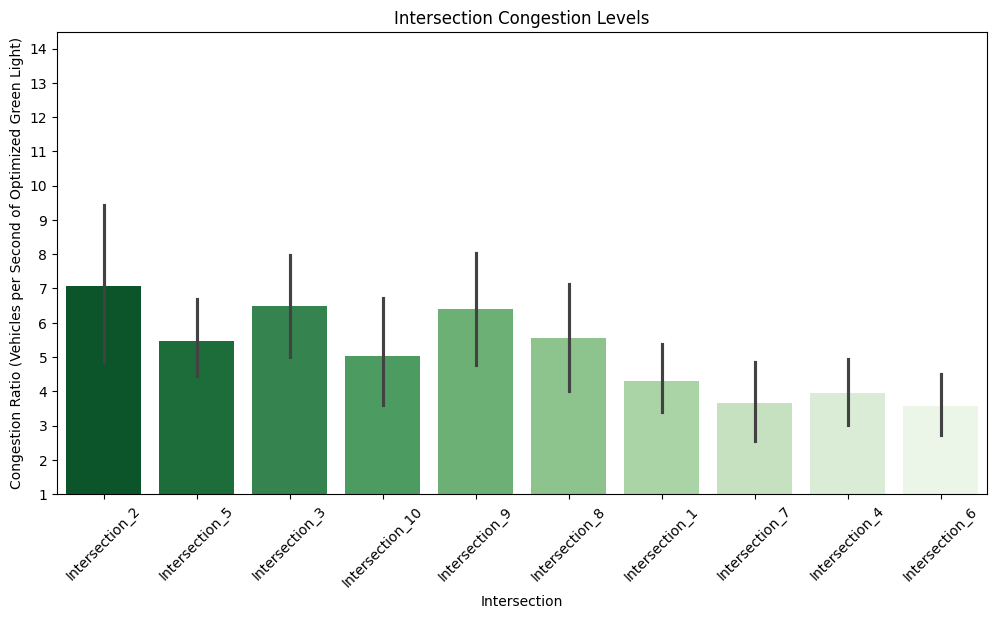

In [ ]:
optimized_signals["congestion_ratio"] = optimized_signals["Vehicle_Count"] / optimized_signals["Optimized_Green_Light"]
sorted_congestion = optimized_signals.sort_values("congestion_ratio", ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x="Intersection", y="congestion_ratio", data=sorted_congestion, palette="Greens_r")
plt.xlabel("Intersection")
plt.ylabel("Congestion Ratio (Vehicles per Second of Optimized Green Light)")
plt.title("Intersection Congestion Levels")
plt.xticks(rotation=45)
plt.ylim(1, max(sorted_congestion["congestion_ratio"]) + 1)  # Start from 1
plt.yticks(range(1, int(max(sorted_congestion["congestion_ratio"])) + 2))

plt.show()

In [ ]:
# intersection_traffic = traffic_data.groupby("Intersection")["Vehicle_Count"].sum().reset_index()
# plt.figure(figsize=(12, 6))
# sns.barplot(x="Intersection", y="Vehicle_Count", data=intersection_traffic, palette="viridis")
# plt.xlabel("Intersection")
# plt.ylabel("Total Vehicle Count")
# plt.title("Traffic Flow by Intersection")
# plt.xticks(rotation=45)
# plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# hourly_traffic = traffic_data.groupby("Hour")["Vehicle_Count"].sum().reset_index()

# plt.figure(figsize=(10, 5))
# sns.lineplot(x="Hour", y="Vehicle_Count", data=hourly_traffic, marker="o")
# plt.axvspan(7, 10, color='red', alpha=0.2, label='Morning Peak')
# plt.axvspan(17, 20, color='red', alpha=0.2, label='Evening Peak')
# plt.xlabel("Hour of the Day")
# plt.ylabel("Total Vehicles")
# plt.title("Traffic Flow by Hour")
# plt.legend()
# plt.grid()
# plt.show()

In [ ]:
# import pandas as pd
# import numpy as np

# # ============================================
# # STEP 1: Merge and Prepare Data
# # ============================================
# # (Assumes that 'traffic_data' and 'signal_data' DataFrames are already defined)

# # Aggregate traffic counts by Intersection and Hour
# merged_traffic = traffic_data.groupby(["Intersection", "Hour"], as_index=False)["Vehicle_Count"].sum()

# # Merge the aggregated traffic data with signal timing data (station data)
# merged_data = merged_traffic.merge(signal_data, on="Intersection", how="inner")

# # Sort by Intersection and Hour for time-series analysis
# merged_data = merged_data.sort_values(["Intersection", "Hour"])
# print("Merged Data (first few rows):")
# print(merged_data.head())

# # ============================================
# # STEP 2: Adaptive Signal Timing Optimization
# # ============================================
# def adjust_signal_timing(df, scaling_factor=30):
#     """
#     Adjusts the signal timing based on the current vehicle count.
#     The idea is to extend the green light and reduce the red light when
#     traffic volume increases.

#     Parameters:
#         df (DataFrame): Must contain the following columns:
#             - 'Vehicle_Count'
#             - 'Green_Light_Duration'
#             - 'Red_Light_Duration'
#         scaling_factor (int): Controls the impact of the vehicle count.

#     Returns:
#         DataFrame: Selected columns including optimized timings.
#     """
#     # Calculate an adjustment factor based on the vehicle count.
#     df["Delta_Green"] = (df["Vehicle_Count"]) / scaling_factor

#     # Increase the green light duration by Delta_Green
#     df["Optimized_Green_Light"] = df["Green_Light_Duration"] + df["Delta_Green"]

#     # Decrease the red light duration by Delta_Green
#     df["Optimized_Red_Light"] = df["Red_Light_Duration"] - df["Delta_Green"]

#     return df[["Intersection", "Hour", "Vehicle_Count", "Optimized_Green_Light", "Optimized_Red_Light"]]

# # Apply the signal timing adjustment function
# optimized_signals = adjust_signal_timing(merged_data)
# pd.set_option("display.max_rows", None)
# pd.set_option("display.max_columns", None)
# pd.set_option("display.width", 1000)
# # print("\nOptimized Signal Timings:")
# # print(optimized_signals)

# # ============================================
# # STEP 3: Optimized Intersection Layout Recommendation
# # ============================================
# def optimize_intersection_layout(df, capacity_per_lane=500, min_lanes=1, max_lanes=4):
#     """
#     Recommends an optimized intersection layout (in terms of lane count) based on
#     the average hourly vehicle count.

#     Parameters:
#         df (DataFrame): Must contain at least the columns 'Intersection' and 'Vehicle_Count'.
#         capacity_per_lane (int): The estimated maximum number of vehicles per hour per lane.
#         min_lanes (int): Minimum number of lanes to recommend.
#         max_lanes (int): Maximum number of lanes to recommend.

#     Returns:
#         DataFrame: A summary with average vehicle counts and recommended lane count per intersection.
#     """
#     # Compute the average vehicle count per intersection
#     avg_counts = df.groupby("Intersection")["Vehicle_Count"].mean().reset_index()
#     avg_counts.rename(columns={"Vehicle_Count": "Avg_Vehicle_Count"}, inplace=True)

#     # Determine the recommended number of lanes using a ceiling function
#     avg_counts["Recommended_Lanes"] = np.ceil(avg_counts["Avg_Vehicle_Count"] / capacity_per_lane).astype(int)

#     # Ensure the recommendation stays within the allowed limits
#     avg_counts["Recommended_Lanes"] = avg_counts["Recommended_Lanes"].clip(lower=min_lanes, upper=max_lanes)

#     return avg_counts

# # Apply the layout optimization function on the merged data
# optimized_layout = optimize_intersection_layout(merged_data, capacity_per_lane=500, min_lanes=1, max_lanes=4)
# # print("\nOptimized Intersection Layout Recommendations:")
# # print(optimized_layout)

# # ============================================
# # STEP 4: (Optional) Combine the Results
# # ============================================
# # Merge the optimized signal timings with the layout recommendations
# final_optimized = optimized_signals.merge(optimized_layout, on="Intersection", how="left")
# print("\nFinal Optimized Data (Signal Timings and Layout):")
# print(final_optimized[['Intersection', 'Hour', 'Vehicle_Count', 'Optimized_Green_Light',
#                          'Optimized_Red_Light', 'Recommended_Lanes']])
